In [40]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict,Annotated, Literal
from langchain_core.messages import BaseMessage,HumanMessage, SystemMessage, AIMessage
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
 

from dotenv import load_dotenv
load_dotenv()


llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)


In [41]:
class queryClassificationSchema(BaseModel):
    intent : Literal['complain', 'inquiry', 'feedback'] = Field(description = 'Sentiment of the email')


class complainSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')


class inquirySchema(BaseModel):
    inquiry_type: Literal["Product", "Pricing", "Availability", "Feature", "Other"] = Field(description='The category of inquiry being made by the user')
    specificity: Literal["vague", "moderate", "specific"] = Field(description='How specific or detailed the inquiry is')
    intent: Literal["purchase", "comparison", "general_info", "technical"] = Field(description='The underlying intent behind the inquiry')


class feedbackSchema(BaseModel):
    sentiment: Literal["positive", "neutral", "mixed", "negative"] = Field(description='The overall sentiment of the feedback')
    feedback_type: Literal["Feature Request", "Praise", "Suggestion", "General"] = Field(description='The type of feedback provided by the user')
    detail_level: Literal["brief", "moderate", "detailed"] = Field(description='How detailed or elaborate the feedback is')


structured_model_1 = llm.with_structured_output(queryClassificationSchema)
structured_model_2 = llm.with_structured_output(complainSchema)
structured_model_3 = llm.with_structured_output(inquirySchema)
structured_model_4 = llm.with_structured_output(feedbackSchema)



In [42]:
prompt = 'software is too bad, I will never purchase again'
structured_model_2.invoke(prompt).tone

'angry'

In [43]:
# state
class ReviewState(TypedDict):

    # Input
    user_review: str
    email_subject: str  
 
    intent: Literal['complain', 'inquiry', 'feedback']
    response : str

    # Structured extraction for each node type of complain, inquiry , feedback
    complain_details: dict   
    inquiry_details: dict     
    feedback_details: dict    



In [44]:
   
def query_classification(state: ReviewState):
    messages = [
        SystemMessage(content="""You are an expert email intent classifier. Your job is to analyze incoming customer emails and classify them into exactly one of three categories:
- "complain": The customer is reporting a problem, expressing dissatisfaction, or describing a negative experience with the product or service.
- "inquiry": The customer is asking a question, seeking information, or requesting clarification about the product, service, pricing, or features.
- "feedback": The customer is sharing their experience, opinion, suggestion, or review — whether positive, neutral, or constructive — without necessarily reporting an issue or asking a question.
Carefully consider both the email subject and body to determine the primary intent. If the email contains multiple intents, classify based on the dominant one."""),
        HumanMessage(content=f"""Classify the following customer email.
Email Subject: {state['email_subject']}
Email Body:
{state['user_review']}""")
    ]
   
    response = structured_model_1.invoke(messages)
    return {"intent": response.intent}




def complain(state: ReviewState):
    messages = [
        SystemMessage(content="""You are a complaint analysis expert. Analyze the customer complaint email and extract:
- The type of issue (UX, Performance, Bug, Support, or Other)
- The emotional tone (angry, frustrated, disappointed, or calm)
- The urgency level (low, medium, or high)"""),
        HumanMessage(content=f"""Analyze this complaint email:
Email Subject: {state['email_subject']}
Email Body:
{state['user_review']}""")
    ]
    
    response = structured_model_2.invoke(messages)
    return {'complain_details': response.model_dump()}




def inquiry(state: ReviewState):
    messages = [
        SystemMessage(content="""You are a customer inquiry analyst. Analyze the customer inquiry email and extract:
- The type of inquiry (Product, Pricing, Availability, Feature, or Other)
- How specific the inquiry is (vague, moderate, or specific)
- The underlying intent (purchase, comparison, general_info, or technical)"""),
        HumanMessage(content=f"""Analyze this inquiry email:
Email Subject: {state['email_subject']}
Email Body:
{state['user_review']}""")
    ]
   
    response = structured_model_3.invoke(messages)
    return {'inquiry_details': response.model_dump()}




def feedback(state: ReviewState):
    messages = [
        SystemMessage(content="""You are a customer feedback analyst. Analyze the customer feedback email and extract:
- The overall sentiment (positive, neutral, mixed, or negative)
- The type of feedback (Feature Request, Praise, Suggestion, or General)
- The detail level (brief, moderate, or detailed)"""),
        HumanMessage(content=f"""Analyze this feedback email:
Email Subject: {state['email_subject']}
Email Body:
{state['user_review']}""")
    ]
    
    response = structured_model_4.invoke(messages)
    return {'feedback_details': response.model_dump()}




def negative_response(state: ReviewState):
    complain_details = state['complain_details']

    messages = [
        SystemMessage(content=f"""You are a professional customer support representative. 
Write a sincere, empathetic apology email in response to a customer complaint.

Complaint Details:
- Issue Type: {complain_details['issue_type']}
- Customer Tone: {complain_details['tone']}
- Urgency: {complain_details['urgency']}

Guidelines:
- If tone is "angry" or "frustrated", be extra empathetic and acknowledge their frustration.
- If urgency is "high", assure them of immediate priority and provide a timeline.
- If urgency is "medium", provide a reasonable timeline for resolution.
- If urgency is "low", thank them for bringing it to attention.
- Always include: acknowledgment of the issue, sincere apology, concrete next steps, and a professional closing.
- Keep the response concise but thorough."""),

        HumanMessage(content=f"""Write an apology email responding to this customer complaint.

Original Email Subject: {state['email_subject']}

Original Email:
{state['user_review']}""")
    ]

    response = llm.invoke(messages).content
    return {'response': response}




def inquiry_response(state: ReviewState):
    inquiry_details = state['inquiry_details']

    messages = [
        SystemMessage(content=f"""You are a knowledgeable customer support representative.
Write a helpful, informative email response to a customer inquiry.

Inquiry Details:
- Inquiry Type: {inquiry_details['inquiry_type']}
- Specificity: {inquiry_details['specificity']}
- Customer Intent: {inquiry_details['intent']}

Guidelines:
- If specificity is "vague", ask clarifying questions while providing general helpful information.
- If specificity is "specific", provide a direct and detailed answer.
- If intent is "purchase", include relevant purchasing information and encourage next steps.
- If intent is "comparison", provide objective feature highlights.
- If intent is "technical", be precise and use appropriate technical detail.
- Always be helpful, professional, and encourage follow-up if needed."""),

        HumanMessage(content=f"""Write a helpful response to this customer inquiry.

Original Email Subject: {state['email_subject']}

Original Email:
{state['user_review']}""")
    ]

    response = llm.invoke(messages).content
    return {'response': response}




def feedback_response(state: ReviewState):
    feedback_details = state['feedback_details']

    messages = [
        SystemMessage(content=f"""You are a warm and appreciative customer support representative.
Write a thoughtful email response to customer feedback.

Feedback Details:
- Sentiment: {feedback_details['sentiment']}
- Feedback Type: {feedback_details['feedback_type']}
- Detail Level: {feedback_details['detail_level']}

Guidelines:
- If sentiment is "positive" or feedback type is "Praise", express genuine gratitude and share their kind words with the team.
- If feedback type is "Feature Request", acknowledge the idea, explain it will be shared with the product team, and don't make promises.
- If feedback type is "Suggestion", thank them for the constructive input and mention how it helps improve the product.
- If sentiment is "negative" or "mixed", acknowledge concerns empathetically while thanking them for honest feedback.
- If detail_level is "detailed", match their effort by giving a thorough response.
- Always thank the customer for taking the time to share feedback."""),

        HumanMessage(content=f"""Write a thoughtful response to this customer feedback.

Original Email Subject: {state['email_subject']}

Original Email:
{state['user_review']}""")
    ]

    response = llm.invoke(messages).content
    return {'response': response}




def route_evaluation(state : ReviewState) -> Literal['complain', 'inquiry', 'feedback']:
    if state['intent'] == 'complain':
        return 'complain'
    elif state['intent'] == 'inquiry':
        return 'inquiry'
    else:
        return 'feedback'
     

In [45]:

# graph
graph = StateGraph(ReviewState)


# nodes
graph.add_node('query_classification', query_classification)

graph.add_node('complain', complain)
graph.add_node('inquiry', inquiry)
graph.add_node('feedback', feedback)

graph.add_node('negative_response', negative_response)
graph.add_node('inquiry_response', inquiry_response)
graph.add_node('feedback_response', feedback_response)



# edges
graph.add_edge(START, 'query_classification')
graph.add_conditional_edges('query_classification',
               route_evaluation,
               {
                   'complain': 'complain',         
                   'inquiry': 'inquiry',           
                   'feedback': 'feedback'          
               }
            )

# connect structured output nodes to  response nodes
graph.add_edge('complain', 'negative_response')
graph.add_edge('inquiry', 'inquiry_response')
graph.add_edge('feedback', 'feedback_response')

# connect response nodes to  END
graph.add_edge('negative_response', END)
graph.add_edge('inquiry_response', END)
graph.add_edge('feedback_response', END)


workflow = graph.compile()


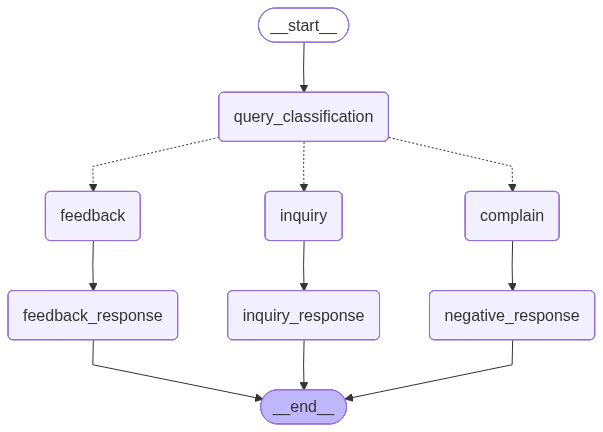

In [47]:
workflow

In [51]:
initial_state = {
    'user_review': "I've been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.",
    'email_subject': "Urgent: Login Bug - App Freezing on Authentication"
}

result = workflow.invoke(initial_state)
 

print('review :', result['user_review'])
print('subject :', result['email_subject'])
print('intent :', result['intent'])
print('response :', result['response'])
print('complain :', result.get('complain_details'))
print('inquiry :', result.get('inquiry_details'))
print('feedback :', result.get('feedback_details'))
# print(result)

review : I've been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.
subject : Urgent: Login Bug - App Freezing on Authentication
intent : complain
response : Subject: Re: Urgent: Login Bug - App Freezing on Authentication

Dear [Customer's Name],

I am deeply sorry to hear that you're experiencing a frustrating issue with our app, specifically with the login functionality. I can only imagine how infuriating it must be to encounter a bug that prevents you from accessing the app, especially after trying to troubleshoot it by reinstalling.

Please know that I acknowledge the severity of this issue and understand that it's unacceptable for our app to malfunction in such a critical area. I want to assure you that we're taking immediate action to resolve this problem. I've escalated your case to our development team, and t